# ECoG Encoding Results Visualization

This notebook generates all results plots and statistical analyses for the neuroscience ECoG encoding experiment.

**Experiment overview:**  
We compare three types of word embeddings (contextual XLM-RoBERTa, sliding-window XLM-RoBERTa, and static FastText) across three languages (English, Hebrew, Arabic) in their ability to predict neural activity recorded via ECoG.

**Encoding results** are time-lag cross-correlations between embedding features and neural signals.  
Each `.npy` file has shape `(2, n_electrodes, 256)` — 2 CV folds, n electrodes, 256 lags from -2.0 to +2.0s at 64 Hz.

**Electrode selection:** electrodes are selected per subject where peak r (max over 0–2s post-onset) in the EN contextual condition exceeds `THRESHOLD = 0.10`.

In [33]:
import re
# === Imports ===
import os
import glob
import warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.ndimage import gaussian_filter1d

try:
    from statsmodels.stats.multitest import multipletests
    HAS_STATSMODELS = True
except ImportError:
    warnings.warn("statsmodels not found — FDR correction will be skipped.")
    HAS_STATSMODELS = False

warnings.filterwarnings('ignore')
print(f"NumPy {np.__version__}, Matplotlib {matplotlib.__version__}")

NumPy 2.2.6, Matplotlib 3.10.9


## Section 1: Configuration & Helper Functions

In [34]:
# ── Configuration ────────────────────────────────────────────────────────────

# Result folders
ctx_folder     = '../results/encoding_results_64Hz_(-2.0,2.0)/contextual/'
static_folder  = '../results/encoding_results_static_64Hz_(-2.0,2.0)/'
sliding_folder = '../results/encoding_results_sliding_64Hz_(-2.0,2.0)/'

RESULTS_DIR = '../results/'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Time-lag axis
LAGS = np.linspace(-2.0, 2.0, 256)   # seconds
DT   = LAGS[1] - LAGS[0]             # ~0.015625 s

# Electrode selection threshold
THRESHOLD = 0.10

# Post-onset selection window (for peak r)
POST_ONSET_RANGE = (0.0, 2.0)

# Conditions
CTX_CONDITIONS     = ['en', 'he', 'ar', 'en+he_ft_residual', 'en+ar_ft_residual', 'noise']
STATIC_CONDITIONS  = ['English', 'Hebrew', 'Arabic',
                      'English+Hebrew_residual', 'English+Arabic_residual', 'English+noise']
SLIDING_CONDITIONS = ['en_sw', 'he_sw', 'ar_sw',
                      'en+he_sw_residual', 'en+ar_sw_residual', 'noise_sw']

# ── Global plot style (Nature-inspired) ──────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.labelsize':    10,
    'axes.titlesize':    11,
    'axes.titleweight':  'bold',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'legend.fontsize':   8,
    'legend.frameon':    True,
    'legend.framealpha': 0.85,
    'legend.edgecolor':  '0.8',
    'font.family':       'sans-serif',
    'font.size':         9,
    'lines.linewidth':   1.8,
    'figure.dpi':        150,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

LABEL_FS  = 10
TICK_FS   = 9
SEM_ALPHA = 0.18
DPI       = 150

# ── Colour palette (colorblind-safe, Nature-style) ────────────────────────────
# Based on Wong (2011) colorblind-safe palette + Nature palette conventions
COL = dict(
    en      = '#1f77b4',   # steel blue  — English
    he      = '#d62728',   # brick red   — Hebrew
    ar      = '#2ca02c',   # forest green — Arabic
    noise   = '#aec7e8',   # light blue-grey — noise/baseline
    sliding = '#ff7f0e',   # burnt orange — sliding window
    static  = '#9467bd',   # muted purple — static
)

# Embedding-type colours (for three-way comparison)
ETYPE_COL = dict(
    contextual = '#1f77b4',
    sliding    = '#ff7f0e',
    static     = '#9467bd',
    noise      = '#aec7e8',
)

print("Configuration loaded.")
print(f"Colour palette: {list(COL.keys())}")


Configuration loaded.


In [35]:
# ── Helper Functions ──────────────────────────────────────────────────────────

def _lag_mask(lag_range):
    """Boolean mask over LAGS for the given (tmin, tmax) range."""
    return (LAGS >= lag_range[0]) & (LAGS <= lag_range[1])


def _find_file(folder, cond_name, subj):
    """Find the .npy file for a given folder / condition / subject.

    Actual naming convention:
        corrs subj=<subj> - <cond_name>.npy
    e.g. corrs subj=01 - en.npy
    """
    # Exact match
    path = os.path.join(folder, f'corrs subj={subj} - {cond_name}.npy')
    if os.path.exists(path):
        return path
    # Glob fallback (handles slight variations)
    matches = glob.glob(os.path.join(folder, f'corrs subj={subj} - {cond_name}*.npy'))
    if matches:
        return sorted(matches)[0]
    return None


def load_curve(folder, cond_name, subj, selected_electrodes, sigma=0):
    """Return mean time-lag curve over selected electrodes for one subject.
    
    Parameters
    ----------
    folder           : str   — result folder path
    cond_name        : str   — condition name (e.g. 'en', 'English')
    subj             : str   — subject identifier
    selected_electrodes : dict  — {subj: array of electrode indices}
    sigma            : float — Gaussian smoothing sigma (in lag samples); 0 = no smoothing
    
    Returns
    -------
    np.ndarray of shape (256,) or None if file not found.
    """
    fpath = _find_file(folder, cond_name, subj)
    if fpath is None:
        return None
    try:
        data = np.load(fpath)          # (2, n_elec, 256)
        data = data.mean(0)            # (n_elec, 256)  — average CV folds
        elec_idx = selected_electrodes.get(subj)
        if elec_idx is None or len(elec_idx) == 0:
            return None
        curve = data[elec_idx, :].mean(0)  # (256,)
        if sigma > 0:
            curve = gaussian_filter1d(curve, sigma=sigma)
        return curve
    except Exception as exc:
        print(f"  Warning: could not load {fpath}: {exc}")
        return None


def get_peak_r(folder, cond_name, subj, selected_electrodes, lag_range=POST_ONSET_RANGE):
    """Return mean peak r over selected electrodes for one subject.
    
    Returns float or None.
    """
    fpath = _find_file(folder, cond_name, subj)
    if fpath is None:
        return None
    try:
        data = np.load(fpath).mean(0)   # (n_elec, 256)
        mask = _lag_mask(lag_range)
        elec_idx = selected_electrodes.get(subj)
        if elec_idx is None or len(elec_idx) == 0:
            return None
        peak_per_elec = data[elec_idx, :][:, mask].max(axis=1)  # (n_selected,)
        return float(peak_per_elec.mean())
    except Exception as exc:
        print(f"  Warning: could not load {fpath}: {exc}")
        return None


def get_subject_peaks(folder, cond_name, selected_electrodes, lag_range=POST_ONSET_RANGE):
    """Return list of per-subject peak r values (one per subject with data)."""
    peaks = []
    for subj in sorted(selected_electrodes.keys()):
        val = get_peak_r(folder, cond_name, subj, selected_electrodes, lag_range)
        if val is not None:
            peaks.append(val)
    return peaks


def grand_avg_curve(folder, cond_name, selected_electrodes, sigma=2):
    """Compute grand-average curve (mean ± SEM across subjects).
    
    Returns (mean_curve, sem_curve, n_subjects) or (None, None, 0).
    """
    curves = []
    for subj in sorted(selected_electrodes.keys()):
        c = load_curve(folder, cond_name, subj, selected_electrodes, sigma=sigma)
        if c is not None:
            curves.append(c)
    if len(curves) == 0:
        return None, None, 0
    arr = np.stack(curves, axis=0)         # (n_subj, 256)
    return arr.mean(0), arr.std(0) / np.sqrt(len(curves)), len(curves)


def cohens_d(a, b):
    """Cohen's d between two paired arrays."""
    diff = np.asarray(a) - np.asarray(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)


def sig_marker(p):
    """Return significance marker string."""
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


def fdr_correct(raw_pvals):
    """Apply Benjamini-Hochberg FDR correction. Returns corrected p-values."""
    if HAS_STATSMODELS and len(raw_pvals) > 0:
        _, corrected, _, _ = multipletests(raw_pvals, method='fdr_bh')
        return corrected
    return np.array(raw_pvals)   # fallback: no correction


def add_axes_decorations(ax, ylabel='Pearson r', xlabel='Time lag (s)'):
    """Add standard decorations: onset line, zero r line, labels, ticks."""
    ax.axvline(0, color='#333333', linestyle='--', linewidth=0.9, zorder=5, alpha=0.7)
    ax.axhline(0, color='#333333', linestyle='-',  linewidth=0.5, alpha=0.25)
    ax.set_xlabel(xlabel, fontsize=LABEL_FS)
    ax.set_ylabel(ylabel, fontsize=LABEL_FS)
    ax.tick_params(labelsize=TICK_FS)
    ax.set_xlim(LAGS[0], LAGS[-1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


print("Helper functions defined.")

Helper functions defined.


## Section 2: Electrode Selection

Discover all subjects from the English contextual result folder, then select electrodes where peak r in the EN contextual condition exceeds `THRESHOLD = 0.10` during the post-onset window (0–2 s).

In [36]:
# ── Discover subjects ─────────────────────────────────────────────────────────
# Files are named: corrs subj=XX - <cond>.npy
# Scan contextual folder for EN condition files to find subject IDs.

def discover_subjects(folder, cond_name):
    """Return sorted list of subject IDs found for given folder/condition."""
    pattern = os.path.join(folder, f'corrs subj=* - {cond_name}.npy')
    subj_ids = []
    for fp in glob.glob(pattern):
        basename = os.path.basename(fp)
        m = re.match(r'corrs subj=([\w]+) -', basename)
        if m:
            sid = m.group(1)
            if sid not in subj_ids:
                subj_ids.append(sid)
    return sorted(subj_ids)


subjects = discover_subjects(ctx_folder, 'en')

if not subjects:
    # Fallback: scan all .npy files matching the pattern
    all_npy = glob.glob(os.path.join(ctx_folder, 'corrs subj=* - en*.npy'))
    for fp in all_npy:
        m = re.match(r'corrs subj=([\w]+) -', os.path.basename(fp))
        if m:
            sid = m.group(1)
            if sid not in subjects:
                subjects.append(sid)
    subjects = sorted(subjects)
    print(f"Fallback subject discovery: found {len(subjects)} subjects.")

print(f"Subjects found: {subjects}")
print(f"Total: {len(subjects)} subjects")


Subjects found: ['01', '02', '03', '04', '05', '06', '07', '08', '09']
Total: 9 subjects


In [37]:
# ── Select electrodes per subject ─────────────────────────────────────────────
# Criterion: max r over post-onset (0–2 s) in EN contextual > THRESHOLD

selected_electrodes = {}   # {subj: np.ndarray of electrode indices}
post_mask = _lag_mask(POST_ONSET_RANGE)

for subj in subjects:
    fpath = _find_file(ctx_folder, 'en', subj)
    if fpath is None:
        print(f"  [{subj}] EN contextual file not found — skipped.")
        continue
    try:
        data = np.load(fpath).mean(0)          # (n_elec, 256)
        peak_per_elec = data[:, post_mask].max(axis=1)   # (n_elec,)
        sel = np.where(peak_per_elec > THRESHOLD)[0]
        selected_electrodes[subj] = sel
        print(f"  [{subj}] {data.shape[0]} total electrodes → {len(sel)} selected "
              f"(threshold={THRESHOLD})")
    except Exception as exc:
        print(f"  [{subj}] Error: {exc}")

total_selected = sum(len(v) for v in selected_electrodes.values())
print(f"\nTotal selected electrodes: {total_selected} across {len(selected_electrodes)} subjects.")

  [01] 99 total electrodes → 44 selected (threshold=0.1)
  [02] 90 total electrodes → 26 selected (threshold=0.1)
  [03] 235 total electrodes → 78 selected (threshold=0.1)
  [04] 143 total electrodes → 60 selected (threshold=0.1)
  [05] 159 total electrodes → 41 selected (threshold=0.1)
  [06] 166 total electrodes → 53 selected (threshold=0.1)
  [07] 116 total electrodes → 24 selected (threshold=0.1)
  [08] 72 total electrodes → 21 selected (threshold=0.1)
  [09] 188 total electrodes → 76 selected (threshold=0.1)

Total selected electrodes: 423 across 9 subjects.


## Section 3: Figure 1 — Grand-Average Time-Lag Curves

Two panels: contextual (left) and static (right). Smoothed (σ=2 samples) curves with SEM shading. Vertical dashed line marks word onset.

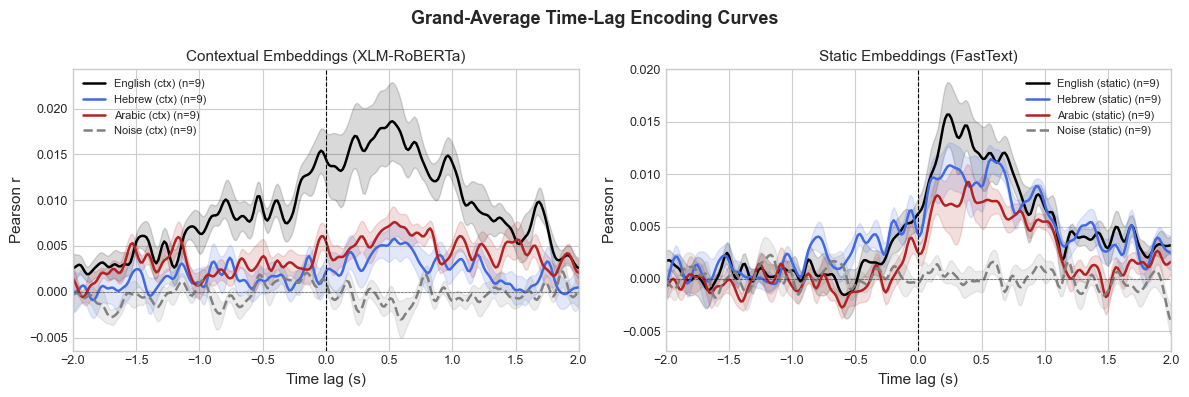

Saved → ../results/fig1_grand_avg_timecurves.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
fig.suptitle('Grand-Average Time-Lag Encoding Curves', fontsize=12, fontweight='bold', y=1.01)

panels = [
    (ctx_folder,
     [('en',    'English',  COL['en'],    '-',  2.0),
      ('he',    'Hebrew',   COL['he'],    '-',  2.0),
      ('ar',    'Arabic',   COL['ar'],    '-',  2.0),
      ('noise', 'Noise',    COL['noise'], '--', 1.2)],
     'Contextual (XLM-RoBERTa)'),
    (static_folder,
     [('English',       'English',  COL['en'],    '-',  2.0),
      ('Hebrew',        'Hebrew',   COL['he'],    '-',  2.0),
      ('Arabic',        'Arabic',   COL['ar'],    '-',  2.0),
      ('English+noise', 'Noise',    COL['noise'], '--', 1.2)],
     'Static (FastText)'),
]

for ax, (folder, conds, title) in zip(axes, panels):
    for cond, label, color, ls, lw in conds:
        mu, sem, n = grand_avg_curve(folder, cond, selected_electrodes, sigma=2)
        if mu is None:
            continue
        ax.plot(LAGS, mu, color=color, linestyle=ls, linewidth=lw,
                label=f'{label} (n={n})', zorder=4)
        ax.fill_between(LAGS, mu - sem, mu + sem, color=color, alpha=SEM_ALPHA, zorder=3)
    add_axes_decorations(ax)
    ax.set_title(title, fontsize=10, pad=6)
    ax.legend(loc='upper left', fontsize=8)

axes[1].set_ylabel('')
plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'fig1_grand_avg_timecurves.png')
plt.savefig(save_path, dpi=DPI)
plt.show()
print(f"Saved → {save_path}")


## Section 4: Figure 2 — Three-Way Embedding Comparison

Compares EN contextual, EN sliding-window, and EN static embeddings on a single panel. Inspired by Goldstein et al. Fig 6 — shows how context window size affects encoding.

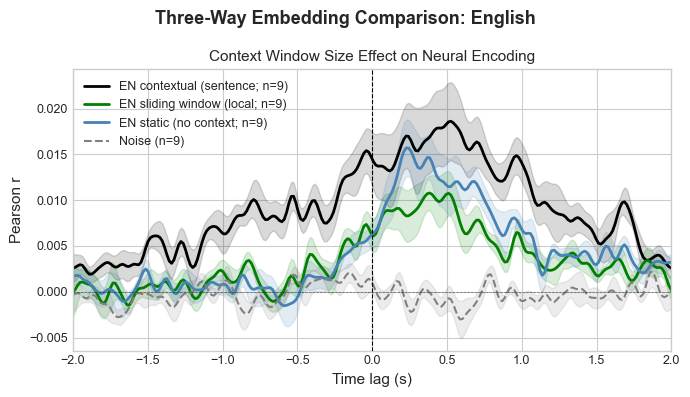

Saved → ../results/fig2_contextual_vs_sliding_vs_static.png


In [39]:
fig, ax = plt.subplots(figsize=(6.5, 4))

specs = [
    (ctx_folder,     'en',      'Contextual (sentence)',     ETYPE_COL['contextual'], '-',  2.0),
    (sliding_folder, 'en_sw',   'Sliding window (local)',    ETYPE_COL['sliding'],    '-',  2.0),
    (static_folder,  'English', 'Static (no context)',       ETYPE_COL['static'],     '-',  2.0),
    (ctx_folder,     'noise',   'Noise baseline',            ETYPE_COL['noise'],      '--', 1.2),
]

for folder, cond, label, color, ls, lw in specs:
    if cond == 'en_sw':
        sw_peaks = get_subject_peaks(folder, cond, selected_electrodes)
        if len(sw_peaks) < 3:
            print(f"  Skipping {cond}: only {len(sw_peaks)} subjects")
            continue
    mu, sem, n = grand_avg_curve(folder, cond, selected_electrodes, sigma=2)
    if mu is None:
        continue
    ax.plot(LAGS, mu, color=color, linestyle=ls, linewidth=lw,
            label=f'{label} (n={n})', zorder=4)
    ax.fill_between(LAGS, mu - sem, mu + sem, color=color, alpha=SEM_ALPHA, zorder=3)

add_axes_decorations(ax)
ax.set_title('Context Window Size Effect — English', fontsize=11, pad=6)
ax.legend(loc='upper left')
plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'fig2_contextual_vs_sliding_vs_static.png')
plt.savefig(save_path, dpi=DPI)
plt.show()
print(f"Saved → {save_path}")


## Section 5: Figure 3 — Language Comparison

Three panels (contextual / sliding / static), each showing EN / HE / AR curves. Addresses: does the brain care which language's embeddings are used?

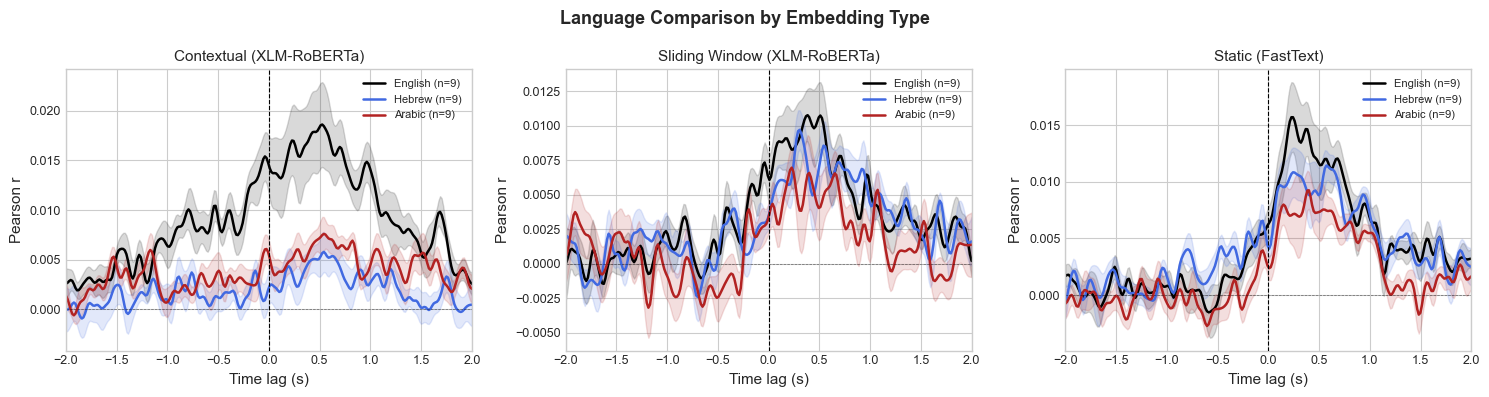

Saved → ../results/fig3_language_comparison.png


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle('Language Comparison by Embedding Type', fontsize=12, fontweight='bold', y=1.01)

lang_cols = [COL['en'], COL['he'], COL['ar']]
lang_lws  = [2.2, 2.0, 2.0]

panels = [
    (ctx_folder,
     [('en', 'English'), ('he', 'Hebrew'), ('ar', 'Arabic')],
     'Contextual (XLM-RoBERTa)'),
    (sliding_folder,
     [('en_sw', 'English'), ('he_sw', 'Hebrew'), ('ar_sw', 'Arabic')],
     'Sliding Window (XLM-RoBERTa)'),
    (static_folder,
     [('English', 'English'), ('Hebrew', 'Hebrew'), ('Arabic', 'Arabic')],
     'Static (FastText)'),
]

for ax, (folder, conds, title) in zip(axes, panels):
    for (cond, label), color, lw in zip(conds, lang_cols, lang_lws):
        mu, sem, n = grand_avg_curve(folder, cond, selected_electrodes, sigma=2)
        if mu is None:
            print(f"  [{title}] {cond} not found")
            continue
        ax.plot(LAGS, mu, color=color, linewidth=lw, label=f'{label} (n={n})', zorder=4)
        ax.fill_between(LAGS, mu - sem, mu + sem, color=color, alpha=SEM_ALPHA, zorder=3)
    add_axes_decorations(ax)
    ax.set_title(title, fontsize=10, pad=6)
    ax.legend(loc='upper left', fontsize=8)

axes[1].set_ylabel('')
axes[2].set_ylabel('')
plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'fig3_language_comparison.png')
plt.savefig(save_path, dpi=DPI)
plt.show()
print(f"Saved → {save_path}")


## Section 6: Figure 4 — Residual Analysis

Shows whether a foreign-language embedding adds unique neural signal beyond the English baseline.  
Left: contextual residuals. Right: static residuals.

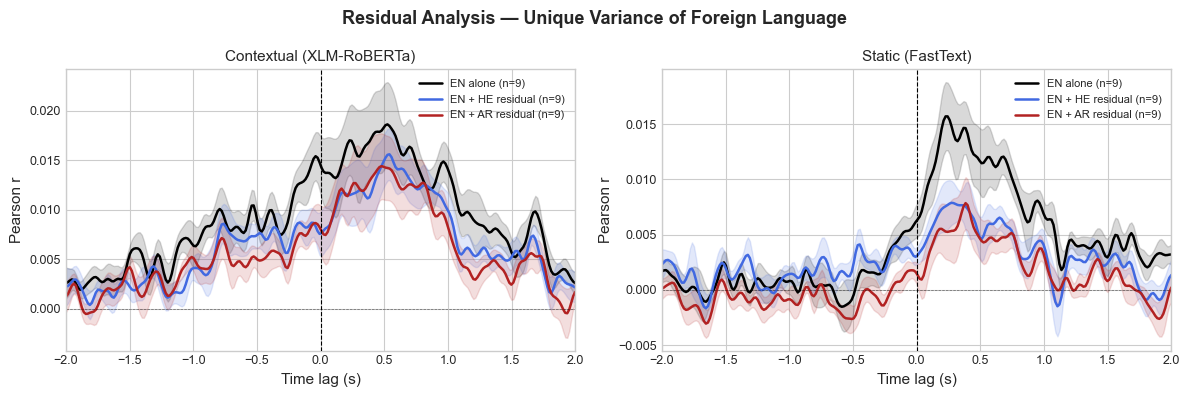

Saved → ../results/fig4_residual_analysis.png


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
fig.suptitle('Residual Analysis — Unique Neural Variance of Foreign Language',
             fontsize=12, fontweight='bold', y=1.01)

residual_panels = [
    (ctx_folder,
     [('en',               'EN alone',        COL['en'],  '-',  2.2),
      ('en+he_ft_residual','EN + HE residual',COL['he'],  '-',  1.8),
      ('en+ar_ft_residual','EN + AR residual',COL['ar'],  '-',  1.8)],
     'Contextual (XLM-RoBERTa)'),
    (static_folder,
     [('English',                'EN alone',        COL['en'],  '-',  2.2),
      ('English+Hebrew_residual','EN + HE residual',COL['he'],  '-',  1.8),
      ('English+Arabic_residual','EN + AR residual',COL['ar'],  '-',  1.8)],
     'Static (FastText)'),
]

for ax, (folder, conds, title) in zip(axes, residual_panels):
    for cond, label, color, ls, lw in conds:
        mu, sem, n = grand_avg_curve(folder, cond, selected_electrodes, sigma=2)
        if mu is None:
            print(f"  [{title}] {cond} not found")
            continue
        ax.plot(LAGS, mu, color=color, linestyle=ls, linewidth=lw,
                label=f'{label} (n={n})', zorder=4)
        ax.fill_between(LAGS, mu - sem, mu + sem, color=color, alpha=SEM_ALPHA, zorder=3)
    add_axes_decorations(ax)
    ax.set_title(title, fontsize=10, pad=6)
    ax.legend(loc='upper left', fontsize=8)

axes[1].set_ylabel('')
plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'fig4_residual_analysis.png')
plt.savefig(save_path, dpi=DPI)
plt.show()
print(f"Saved → {save_path}")


## Section 7: Figure 5 — Peak r Bar Chart with Statistical Tests

Bar chart of mean peak r (post-onset, 0–2 s) with SEM error bars. Paired t-tests with FDR correction and Cohen's d effect sizes.

In [42]:
# ── Collect per-subject peak r for each condition ─────────────────────────────
peak_data = {}

bar_specs = [
    # (key,          folder,         cond_name,  group,         color)
    ('ctx_en',       ctx_folder,     'en',              'Contextual', COL['en']),
    ('ctx_he',       ctx_folder,     'he',              'Contextual', COL['he']),
    ('ctx_ar',       ctx_folder,     'ar',              'Contextual', COL['ar']),
    ('ctx_noise',    ctx_folder,     'noise',           'Contextual', COL['noise']),
    ('sw_en',        sliding_folder, 'en_sw',           'Sliding',    COL['en']),
    ('sw_he',        sliding_folder, 'he_sw',           'Sliding',    COL['he']),
    ('sw_ar',        sliding_folder, 'ar_sw',           'Sliding',    COL['ar']),
    ('sw_noise',     sliding_folder, 'noise_sw',        'Sliding',    COL['noise']),
    ('stat_en',      static_folder,  'English',         'Static',     COL['en']),
    ('stat_he',      static_folder,  'Hebrew',          'Static',     COL['he']),
    ('stat_ar',      static_folder,  'Arabic',          'Static',     COL['ar']),
    ('stat_noise',   static_folder,  'English+noise',   'Static',     COL['noise']),
]

for key, folder, cond, group, color in bar_specs:
    vals = get_subject_peaks(folder, cond, selected_electrodes)
    peak_data[key] = vals
    print(f"  {key:20s}: n={len(vals):2d}  mean={np.mean(vals):.3f}" if vals
          else f"  {key:20s}: no data")

print("\nPeak r collection complete.")

  ctx_en              : n= 9  mean=0.118
  ctx_he              : n= 9  mean=0.093
  ctx_ar              : n= 9  mean=0.095
  ctx_noise           : n= 9  mean=0.087
  sw_en               : n= 9  mean=0.098
  sw_he               : n= 9  mean=0.095
  sw_ar               : n= 9  mean=0.093
  sw_noise            : n= 9  mean=0.086
  stat_en             : n= 9  mean=0.099
  stat_he             : n= 9  mean=0.094
  stat_ar             : n= 9  mean=0.092
  stat_noise          : n= 9  mean=0.088

Peak r collection complete.


In [43]:
# ── Paired t-tests with FDR correction ───────────────────────────────────────

def paired_ttest(a, b):
    """Paired t-test on subjects present in both conditions."""
    a, b = np.asarray(a), np.asarray(b)
    n = min(len(a), len(b))
    if n < 3:
        return np.nan, np.nan
    t, p = stats.ttest_rel(a[:n], b[:n])
    return float(t), float(p)


# Define comparisons
comparisons = [
    ('EN ctx vs EN static',   'ctx_en',  'stat_en'),
    ('EN ctx vs noise ctx',   'ctx_en',  'ctx_noise'),
    ('EN ctx vs EN sliding',  'ctx_en',  'sw_en'),
    ('EN sliding vs EN static', 'sw_en', 'stat_en'),
]

raw_ps, valid_comps = [], []
for label, k1, k2 in comparisons:
    d1, d2 = peak_data.get(k1, []), peak_data.get(k2, [])
    n = min(len(d1), len(d2))
    if n < 3:
        print(f"  [{label}]: insufficient data (n={n}) — skipping.")
        continue
    t, p = paired_ttest(d1, d2)
    d = cohens_d(d1[:n], d2[:n])
    valid_comps.append((label, k1, k2, t, p, d))
    raw_ps.append(p)

# FDR correction
corr_ps = fdr_correct(raw_ps) if raw_ps else []

print("\nStatistical comparisons (FDR-corrected):")
cohensd_hdr = "Cohen's d"
print(f"{'Comparison':<35} {'t':>7} {'p_raw':>10} {'p_fdr':>10} {cohensd_hdr:>10} {'sig':>5}")
print('-' * 80)
for i, (label, k1, k2, t, p_raw, d) in enumerate(valid_comps):
    p_fdr = corr_ps[i] if i < len(corr_ps) else p_raw
    print(f"{label:<35} {t:>7.3f} {p_raw:>10.4f} {p_fdr:>10.4f} {d:>10.3f} {sig_marker(p_fdr):>5}")


Statistical comparisons (FDR-corrected):
Comparison                                t      p_raw      p_fdr  Cohen's d   sig
--------------------------------------------------------------------------------
EN ctx vs EN static                  22.329     0.0000     0.0000      7.443   ***
EN ctx vs noise ctx                  13.849     0.0000     0.0000      4.616   ***
EN ctx vs EN sliding                 11.979     0.0000     0.0000      3.993   ***
EN sliding vs EN static              -0.218     0.8332     0.8332     -0.073    ns


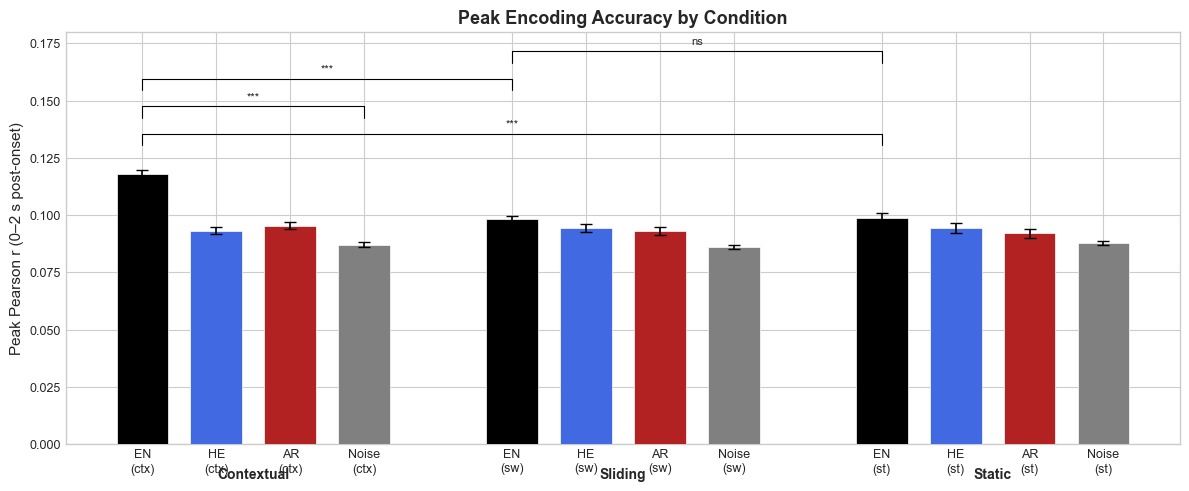

Saved → ../results/fig5_peak_r_barplot.png


In [44]:
if not bar_means:
    print("  Fig5: No data — skipping.")
else:
    fig, ax = plt.subplots(figsize=(11, 4.5))

    # Draw bars
    bar_objs = ax.bar(bar_positions, bar_means, color=bar_colors,
                      edgecolor='white', linewidth=0.6, width=0.7, zorder=3)

    # Error bars
    ax.errorbar(bar_positions, bar_means, yerr=bar_sems, fmt='none',
                color='#333333', capsize=3, capthick=0.8, linewidth=0.9, zorder=4)

    # Individual subject dots (jittered)
    rng = np.random.default_rng(7)
    key_order = [k for g in group_keys for k in g if peak_data.get(k)]
    for pos, key, color in zip(bar_positions,
                                key_order,
                                bar_colors):
        vals = peak_data.get(key, [])
        jitter = rng.uniform(-0.18, 0.18, size=len(vals))
        ax.scatter(pos + jitter, vals, color=color, s=18, zorder=5,
                   edgecolors='white', linewidth=0.4, alpha=0.85)

    ax.set_xticks(bar_positions)
    ax.set_xticklabels(bar_labels, fontsize=8)
    ax.set_ylabel('Peak Pearson r  (0–2 s post-onset)', fontsize=LABEL_FS)
    ax.set_title('Peak Encoding Accuracy by Condition', fontsize=11, pad=8)
    ax.axhline(0, color='#333333', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Group labels
    y_bot = ax.get_ylim()[0]
    for grp, center in zip(groups, group_centers):
        ax.text(center, y_bot - 0.006, grp, ha='center', va='top',
                fontsize=9, fontweight='bold', color='#333333')
        x_lo, x_hi = [r for g, r in zip(groups, group_x_ranges) if g == grp][0]
        ax.plot([x_lo, x_hi], [y_bot - 0.002, y_bot - 0.002],
                color='#aaaaaa', linewidth=1.0, clip_on=False)

    # Significance brackets
    key_to_pos = {k: p for k, p in zip(key_order, bar_positions)}
    bracket_height = max(bar_means) * 1.12 if bar_means else 0.1
    for i, (label, k1, k2, t, p_raw, d) in enumerate(valid_comps):
        p_fdr = corr_ps[i] if i < len(corr_ps) else p_raw
        marker = sig_marker(p_fdr)
        if marker == 'ns':
            continue
        x1 = key_to_pos.get(k1)
        x2 = key_to_pos.get(k2)
        if x1 is None or x2 is None:
            continue
        bh = bracket_height + i * 0.011
        ax.plot([x1, x1, x2, x2], [bh - 0.004, bh, bh, bh - 0.004],
                color='#333333', linewidth=0.8)
        ax.text((x1 + x2) / 2, bh + 0.001, marker,
                ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, 'fig5_peak_r_barplot.png')
    plt.savefig(save_path, dpi=DPI)
    plt.show()
    print(f"Saved → {save_path}")


## Section 8: Figure 6 — Electrode Encoding Profile (Ranked)

All electrodes pooled across subjects, sorted by EN contextual peak r. Shows how EN contextual, EN static, EN sliding (if available), and noise compare electrode-by-electrode. Inspired by dataset paper Figure 3a.

In [45]:
# ── Collect per-electrode peak r ──────────────────────────────────────────────

def collect_electrode_peaks(folder, cond_name, selected_electrodes, lag_range=POST_ONSET_RANGE):
    """Return concatenated array of per-electrode peak r across all subjects."""
    mask = _lag_mask(lag_range)
    all_peaks = []
    for subj in sorted(selected_electrodes.keys()):
        fpath = _find_file(folder, cond_name, subj)
        elec_idx = selected_electrodes.get(subj, [])
        if fpath is None or len(elec_idx) == 0:
            continue
        try:
            data = np.load(fpath).mean(0)       # (n_elec, 256)
            peaks = data[elec_idx, :][:, mask].max(axis=1)
            all_peaks.append(peaks)
        except Exception as exc:
            print(f"  [{subj}] {cond_name}: {exc}")
    return np.concatenate(all_peaks) if all_peaks else np.array([])


elec_ctx   = collect_electrode_peaks(ctx_folder,     'en',      selected_electrodes)
elec_stat  = collect_electrode_peaks(static_folder,  'English', selected_electrodes)
elec_sw    = collect_electrode_peaks(sliding_folder, 'en_sw',   selected_electrodes)
elec_noise = collect_electrode_peaks(ctx_folder,     'noise',   selected_electrodes)

print(f"Electrode counts — ctx: {len(elec_ctx)}, static: {len(elec_stat)}, "
      f"sliding: {len(elec_sw)}, noise: {len(elec_noise)}")

Electrode counts — ctx: 423, static: 423, sliding: 423, noise: 423


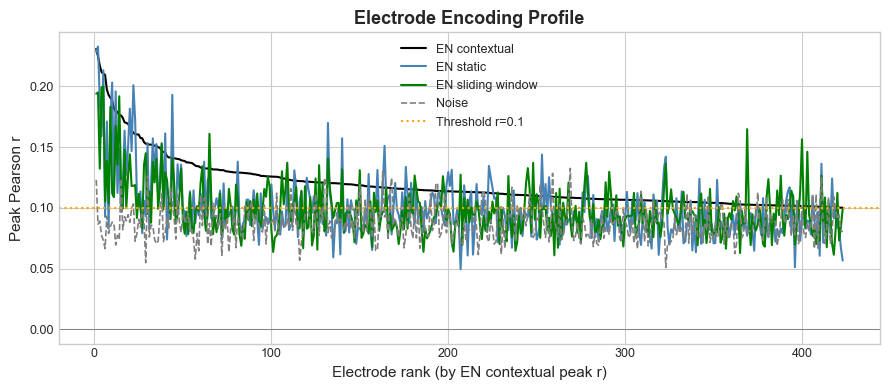

Saved → ../results/fig6_electrode_profile.png


In [46]:
if len(elec_ctx) == 0:
    print("  Fig6: No EN contextual electrode data — skipping.")
else:
    sort_idx = np.argsort(elec_ctx)[::-1]
    ranks    = np.arange(1, len(elec_ctx) + 1)

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(ranks, elec_ctx[sort_idx], color=ETYPE_COL['contextual'],
            linewidth=1.8, label='EN contextual', zorder=4)

    if len(elec_stat) == len(elec_ctx):
        ax.plot(ranks, elec_stat[sort_idx], color=ETYPE_COL['static'],
                linewidth=1.8, label='EN static', zorder=3)
    elif len(elec_stat) > 0:
        s_idx = np.argsort(elec_stat)[::-1]
        ax.plot(np.arange(1, len(elec_stat)+1), elec_stat[s_idx],
                color=ETYPE_COL['static'], linewidth=1.8, label='EN static (own rank)', zorder=3)

    if len(elec_sw) >= 3:
        if len(elec_sw) == len(elec_ctx):
            ax.plot(ranks, elec_sw[sort_idx], color=ETYPE_COL['sliding'],
                    linewidth=1.8, label='EN sliding window', zorder=3)
        else:
            sw_idx = np.argsort(elec_sw)[::-1]
            ax.plot(np.arange(1, len(elec_sw)+1), elec_sw[sw_idx],
                    color=ETYPE_COL['sliding'], linewidth=1.8,
                    label='EN sliding (own rank)', zorder=3)

    if len(elec_noise) > 0:
        n_data = elec_noise[sort_idx] if len(elec_noise)==len(elec_ctx) else elec_noise[np.argsort(elec_noise)[::-1]]
        n_ranks = ranks if len(elec_noise)==len(elec_ctx) else np.arange(1, len(elec_noise)+1)
        ax.plot(n_ranks, n_data, color=ETYPE_COL['noise'], linestyle='--',
                linewidth=1.2, label='Noise', zorder=2)

    ax.axhline(THRESHOLD, color='#e08000', linestyle=':', linewidth=1.5,
               label=f'Selection threshold (r={THRESHOLD})', zorder=5)
    ax.axhline(0, color='#333333', linewidth=0.5, alpha=0.3)

    ax.set_xlabel('Electrode rank (sorted by EN contextual peak r)', fontsize=LABEL_FS)
    ax.set_ylabel('Peak Pearson r', fontsize=LABEL_FS)
    ax.set_title('Electrode Encoding Profile', fontsize=11, pad=6)
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, 'fig6_electrode_profile.png')
    plt.savefig(save_path, dpi=DPI)
    plt.show()
    print(f"Saved → {save_path}")


## Section 9: Figure 7 — Pre- vs Post-Onset Analysis

Compute mean r in two windows (pre-onset: -0.8–0 s; post-onset: 0–0.8 s) for each condition. Scatter + grouped bar chart. Inspired by Goldstein et al. Fig 4.

In [47]:
PRE_RANGE  = (-0.8, 0.0)
POST_RANGE = (0.0,  0.8)

pre_mask  = _lag_mask(PRE_RANGE)
post_mask2 = _lag_mask(POST_RANGE)


def window_mean_r(folder, cond_name, subj, selected_electrodes, mask):
    """Mean r over selected electrodes and time window for one subject."""
    fpath = _find_file(folder, cond_name, subj)
    if fpath is None:
        return None
    try:
        data = np.load(fpath).mean(0)   # (n_elec, 256)
        elec_idx = selected_electrodes.get(subj)
        if elec_idx is None or len(elec_idx) == 0:
            return None
        return float(data[elec_idx, :][:, mask].mean())
    except:
        return None


# Conditions for pre/post analysis
prepost_specs = [
    ('EN ctx',   ctx_folder,     'en'),
    ('HE ctx',   ctx_folder,     'he'),
    ('AR ctx',   ctx_folder,     'ar'),
    ('EN sw',    sliding_folder, 'en_sw'),
    ('EN static',static_folder,  'English'),
    ('Noise',    ctx_folder,     'noise'),
]

pre_vals, post_vals, valid_labels = [], [], []

for label, folder, cond in prepost_specs:
    pre_list, post_list = [], []
    for subj in sorted(selected_electrodes.keys()):
        pv = window_mean_r(folder, cond, subj, selected_electrodes, pre_mask)
        po = window_mean_r(folder, cond, subj, selected_electrodes, post_mask2)
        if pv is not None and po is not None:
            pre_list.append(pv)
            post_list.append(po)
    if pre_list:
        pre_vals.append(np.mean(pre_list))
        post_vals.append(np.mean(post_list))
        valid_labels.append(label)
    else:
        print(f"  Fig7: '{label}' no data — skipping.")

print(f"Pre/post data for {len(valid_labels)} conditions.")

Pre/post data for 6 conditions.


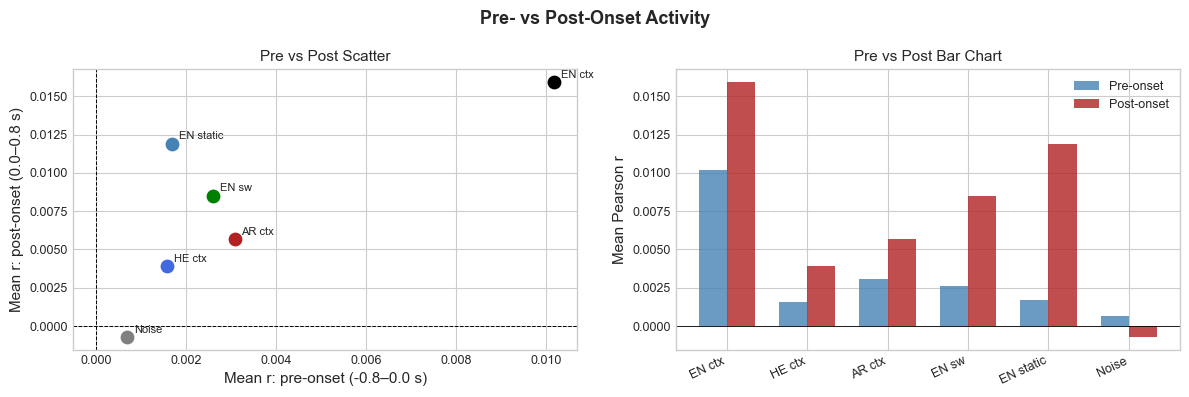

Saved → ../results/fig7_pre_vs_post_onset.png


In [48]:
if not valid_labels:
    print("  Fig7: No data — skipping.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle('Pre- vs Post-Onset Neural Activity',
                 fontsize=12, fontweight='bold', y=1.01)

    scatter_cols = [COL['en'], COL['he'], COL['ar'],
                    ETYPE_COL['sliding'], ETYPE_COL['static'], COL['noise']]

    # ── Scatter ──────────────────────────────────────────────────────────────
    ax = axes[0]
    for i, (lbl, pv, po) in enumerate(zip(valid_labels, pre_vals, post_vals)):
        c = scatter_cols[i % len(scatter_cols)]
        ax.scatter(pv, po, color=c, s=90, zorder=4, edgecolors='white', linewidth=0.6)
        ax.annotate(lbl, (pv, po), textcoords='offset points',
                    xytext=(6, 4), fontsize=8, color='#333333')
    # Diagonal reference (pre == post)
    all_vals = pre_vals + post_vals
    lim = (min(all_vals) - 0.002, max(all_vals) + 0.002)
    ax.plot(lim, lim, color='#aaaaaa', linestyle='--', linewidth=0.8, zorder=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.axvline(0, color='#333333', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.axhline(0, color='#333333', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.set_xlabel(f'Mean r: pre-onset ({PRE_RANGE[0]}–{PRE_RANGE[1]} s)', fontsize=LABEL_FS)
    ax.set_ylabel(f'Mean r: post-onset ({POST_RANGE[0]}–{POST_RANGE[1]} s)', fontsize=LABEL_FS)
    ax.set_title('Pre vs Post Scatter', fontsize=10, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── Grouped bar ───────────────────────────────────────────────────────────
    ax = axes[1]
    x = np.arange(len(valid_labels))
    w = 0.38
    ax.bar(x - w/2, pre_vals,  w, label='Pre-onset',
           color='#4e79a7', alpha=0.9, edgecolor='white', linewidth=0.5)
    ax.bar(x + w/2, post_vals, w, label='Post-onset',
           color='#e15759', alpha=0.9, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(valid_labels, rotation=25, ha='right', fontsize=8)
    ax.axhline(0, color='#333333', linewidth=0.6)
    ax.set_ylabel('Mean Pearson r', fontsize=LABEL_FS)
    ax.set_title('Pre vs Post Bar Chart', fontsize=10, pad=6)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, 'fig7_pre_vs_post_onset.png')
    plt.savefig(save_path, dpi=DPI)
    plt.show()
    print(f"Saved → {save_path}")


## Section 10: Figure 8 — Per-Subject Peak r Distribution

Violin + box plot with individual subject points, for key conditions. Shows individual variability across the 9 subjects. Inspired by Goldstein et al.

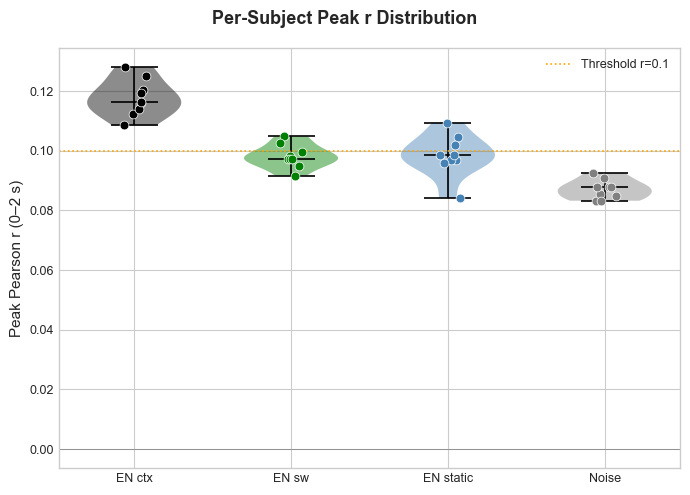

Saved → ../results/fig8_per_subject_peak_r.png


In [49]:
violin_specs = [
    ('EN contextual',   ctx_folder,     'en',      ETYPE_COL['contextual']),
    ('EN sliding',      sliding_folder, 'en_sw',   ETYPE_COL['sliding']),
    ('EN static',       static_folder,  'English', ETYPE_COL['static']),
    ('Noise',           ctx_folder,     'noise',   ETYPE_COL['noise']),
]

violin_data, violin_labels, violin_colors = [], [], []
for label, folder, cond, color in violin_specs:
    vals = get_subject_peaks(folder, cond, selected_electrodes)
    if len(vals) >= 2:
        violin_data.append(vals)
        violin_labels.append(label)
        violin_colors.append(color)
    else:
        print(f"  Fig8: '{label}' n={len(vals)} — skipping.")

if not violin_data:
    print("  Fig8: No data — skipping.")
else:
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    positions = np.arange(1, len(violin_data) + 1)
    vp = ax.violinplot(violin_data, positions=positions, showmedians=True,
                       showextrema=True, widths=0.55)

    for body, color in zip(vp['bodies'], violin_colors):
        body.set_facecolor(color)
        body.set_edgecolor('white')
        body.set_alpha(0.55)
        body.set_linewidth(0.8)
    for part in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
        if part in vp:
            vp[part].set_edgecolor('#333333')
            vp[part].set_linewidth(1.2)

    rng = np.random.default_rng(42)
    for pos, vals, color in zip(positions, violin_data, violin_colors):
        jitter = rng.uniform(-0.1, 0.1, size=len(vals))
        ax.scatter(pos + jitter, vals, color=color, s=45, zorder=5,
                   edgecolors='white', linewidth=0.5)

    ax.set_xticks(positions)
    ax.set_xticklabels(violin_labels, fontsize=9)
    ax.set_ylabel('Peak Pearson r  (0–2 s post-onset)', fontsize=LABEL_FS)
    ax.set_title('Per-Subject Peak Encoding Accuracy', fontsize=11, pad=6)
    ax.axhline(0, color='#333333', linewidth=0.5, alpha=0.3)
    ax.axhline(THRESHOLD, color='#e08000', linestyle=':', linewidth=1.2,
               label=f'Threshold r={THRESHOLD}')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, 'fig8_per_subject_peak_r.png')
    plt.savefig(save_path, dpi=DPI)
    plt.show()
    print(f"Saved → {save_path}")


## Section 11: Statistical Summary Table

All key conditions: mean peak r ± SEM, p-value vs noise (FDR-corrected), p-value vs EN contextual, Cohen's d vs EN contextual, significance marker.

In [50]:
summary_specs = [
    # (display_label, key_in_peak_data)
    ('EN contextual',           'ctx_en'),
    ('HE contextual',           'ctx_he'),
    ('AR contextual',           'ctx_ar'),
    ('Noise contextual',        'ctx_noise'),
    ('EN sliding window',       'sw_en'),
    ('HE sliding window',       'sw_he'),
    ('AR sliding window',       'sw_ar'),
    ('Noise sliding',           'sw_noise'),
    ('EN static',               'stat_en'),
    ('HE static',               'stat_he'),
    ('AR static',               'stat_ar'),
    ('Noise static',            'stat_noise'),
    ('EN+HE residual (ctx)',    'ctx_en_he_res'),
    ('EN+AR residual (ctx)',    'ctx_en_ar_res'),
    ('EN+HE residual (static)', 'stat_en_he_res'),
    ('EN+AR residual (static)', 'stat_en_ar_res'),
]

# Load any residual conditions not yet in peak_data
extra_specs = [
    ('ctx_en_he_res',  ctx_folder,    'en+he_ft_residual'),
    ('ctx_en_ar_res',  ctx_folder,    'en+ar_ft_residual'),
    ('stat_en_he_res', static_folder, 'English+Hebrew_residual'),
    ('stat_en_ar_res', static_folder, 'English+Arabic_residual'),
]
for key, folder, cond in extra_specs:
    if key not in peak_data:
        peak_data[key] = get_subject_peaks(folder, cond, selected_electrodes)

# Reference arrays
ref_noise = peak_data.get('ctx_noise', [])
ref_en    = peak_data.get('ctx_en', [])

# Gather all raw p-values for FDR
all_rows_tmp = []
for display_label, key in summary_specs:
    vals = peak_data.get(key, [])
    if not vals:
        continue
    n = len(vals)
    mean_r = np.mean(vals)
    sem_r  = np.std(vals, ddof=1) / np.sqrt(n) if n > 1 else np.nan

    # vs noise
    nn = min(n, len(ref_noise))
    if nn >= 3 and key != 'ctx_noise':
        _, p_noise_raw = stats.ttest_rel(vals[:nn], ref_noise[:nn])
    else:
        p_noise_raw = np.nan

    # vs EN contextual
    ne = min(n, len(ref_en))
    if ne >= 3 and key != 'ctx_en':
        _, p_en_raw = stats.ttest_rel(vals[:ne], ref_en[:ne])
        d_en = cohens_d(vals[:ne], ref_en[:ne])
    else:
        p_en_raw = np.nan
        d_en = np.nan

    all_rows_tmp.append((display_label, key, n, mean_r, sem_r, p_noise_raw, p_en_raw, d_en))

# FDR-correct p-noise and p-en separately
p_noise_raw_list = [r[5] for r in all_rows_tmp if not np.isnan(r[5])]
p_en_raw_list    = [r[6] for r in all_rows_tmp if not np.isnan(r[6])]

p_noise_fdr = list(fdr_correct(p_noise_raw_list))
p_en_fdr    = list(fdr_correct(p_en_raw_list))

noise_fdr_iter = iter(p_noise_fdr)
en_fdr_iter    = iter(p_en_fdr)

cohensd_hdr = "Cohen's d"
# Print table
header = (f"{'Condition':<30} {'n':>3} {'Mean r':>8} {'±SEM':>8} "
          f"{'p_noise':>10} {'p_EN_ctx':>10} {cohensd_hdr:>10} {'sig':>5}")
print(header)
print('─' * len(header))

for (display_label, key, n, mean_r, sem_r, p_noise_raw, p_en_raw, d_en) in all_rows_tmp:
    p_n_str  = '-'
    p_e_str  = '-'
    sig_str  = '-'
    d_str    = '-'

    if not np.isnan(p_noise_raw):
        p_n_fdr = next(noise_fdr_iter)
        p_n_str = f'{p_n_fdr:.4f}'
    if not np.isnan(p_en_raw):
        p_e_fdr = next(en_fdr_iter)
        p_e_str = f'{p_e_fdr:.4f}'
        sig_str = sig_marker(p_e_fdr)
    if not np.isnan(d_en):
        d_str = f'{d_en:.3f}'

    print(f"{display_label:<30} {n:>3} {mean_r:>8.4f} {sem_r:>8.4f} "
          f"{p_n_str:>10} {p_e_str:>10} {d_str:>10} {sig_str:>5}")

print('\nNote: p-values are FDR-corrected (Benjamini-Hochberg).')
print('Significance: ns p≥0.05 | * p<0.05 | ** p<0.01 | *** p<0.001')

SyntaxError: unterminated string literal (detected at line 76) (306015248.py, line 76)